# Train one DNN based on DNN_optimization.ipynb results

In [1]:
# tensorflow version used: 2.1.0
# keras 2.3.1

In [2]:
from ZV_functions import *
import tensorflow as tf
from matplotlib import pyplot as plt
import matplotlib
import pandas as pd
matplotlib.rcParams.update({'font.size': 16})
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.constraints import MaxNorm as maxnorm
import keras.backend as k
from tensorflow.keras import regularizers


Using TensorFlow backend.


In [3]:
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 20}

matplotlib.rc('font', **font)

plt.rc('legend', fontsize=18) 
plt.rc('axes', titlesize=30)     # fontsize of the axes title
plt.rc('axes', labelsize=24) 

In [6]:
#base_dir='/eos/home-a/ahakimi/www/ZV_analysis'
base_dir='D:\\Travail\\ZV_analysis\\'
#year='2018_SR'
years=['2018_qgl']#,'2017_prefire','2016_prefire'
name='2018_bReq_pruned' #original:20/18
cut='Boosted_SR_bReq'
vers=''
#all feats res = 24
training = 'Pruned_morphed' #'Pruned'

if training == 'Pruned':
    if 'Boosted' in cut:
        features =['mjj_max', 'V_jet_qgl1_morphed','V_jet_qgl2_morphed',  
                 'vbs_jet_qgl1_morphed', 'Zlep_1', 'vbs_jet_qgl2_morphed',
                 'Zlep_2', 'V_jet_eta1', 'V_jet_eta2','dphijj', 
                  'vbs_jet_pt2','vbs_jet_pt1','V_jet_pt2', 'detajj'

                 ]

    elif 'Resolved' in cut:
        features=['mjj_max', 'V_jet_qgl1_morphed','V_jet_qgl2_morphed',  
                 'vbs_jet_qgl1_morphed', 'Zlep_1', 'vbs_jet_qgl2_morphed',
                 'Zlep_2', 'V_jet_eta1', 'V_jet_eta2','dphijj', 
                  'vbs_jet_pt2','vbs_jet_pt1','V_jet_pt2', 'detajj'

                 ]# 'Lep_eta2','V_jet_mass','V_jet_pt1','Lep_eta1','vbs_jet_pt1','V_jet_pt2',
    #'dphijj_mjjmax', 'vbs_jet_pt2', 'detajj_mjjmax',

if training == 'Pruned_btag':
    if 'Boosted' in cut:
        features =['Lep_pt1', 
           
           'FatJet_pt', 'FatJeteta',
           'Zlep_1', 'Zlep_2', 
            'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'mjj_max', 'detajj', 
            'njet', 'Zvjet','nbtag' ]


    elif 'Resolved' in cut:
        features=['Lep_pt1','mll','Zlep_1','Zlep_2','vbs_jet_pt2','V_jet_pt1', 'V_jet_pt2',
                  'V_jet_eta1','V_jet_eta2','mjj_max','detajj','dphijj','V_jet_mass',
                  'njet','V_jet_qgl1_morphed']# 'Lep_eta2','V_jet_mass','V_jet_pt1','Lep_eta1','vbs_jet_pt1','V_jet_pt2',
    #'dphijj_mjjmax', 'vbs_jet_pt2', 'detajj_mjjmax'
    
elif training == "Full":
    if 'Boosted' in cut:
        features =['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'FatJet_pt', 'FatJeteta',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'mjj_max', 'detajj', 'dphijj', 
            'njet', 'Zvjet', 'vbs_jet_qgl1_morphed', 'vbs_jet_qgl2_morphed']
    elif 'Resolved' in cut:
        features=['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'V_jet_pt1', 'V_jet_pt2',
           'V_jet_eta1', 'V_jet_eta2',
           'mjj_max', 'detajj', 'dphijj',
           'V_jet_mass', 'njet', 'vbs_jet_qgl1_morphed', 'vbs_jet_qgl2_morphed',
             'V_jet_qgl1_morphed', 'V_jet_qgl2_morphed']
        
if training == 'Pruned_morphed':
    if 'Boosted' in cut:
        features =['Lep_pt1', 'Lep_eta1','Lep_eta2','FatJet_pt','FatJeteta',
            
           'Zlep_1', 'Zlep_2', 'vbs_jet_pt2', 'vbs_jet_eta2',
            
           'mjj_max', 'detajj', 'dphijj',
            'njet',  'Zvjet', ] 
        #,  

    elif 'Resolved' in cut:
        features=['Zlep_1',  'Zlep_2',
            'vbs_jet_pt2',  'V_jet_pt1', 'V_jet_pt2','V_jet_eta1','V_jet_eta2',
           'mjj_max', 'detajj', 
            'njet', 'dphijj', 'V_jet_mass',
             'V_jet_qgl1_morphed',
            'V_jet_qgl2_morphed',] # 'Lep_eta2','V_jet_mass','V_jet_pt1','Lep_eta1','vbs_jet_pt1','V_jet_pt2',
    #'dphijj_mjjmax', 'vbs_jet_pt2', 'detajj_mjjmax',   

    
elif training == "Full_btag":
    if 'Boosted' in cut:
        features =['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'FatJet_pt', 'FatJeteta',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'mjj_max', 'detajj', 'dphijj', 
            'njet', 'Zvjet', 'vbs_jet_qgl1_morphed', 'vbs_jet_qgl2_morphed', 'nbtag']
    elif 'Resolved' in cut:
        features=['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'V_jet_pt1', 'V_jet_pt2',
           'V_jet_eta1', 'V_jet_eta2',
           'mjj_max', 'detajj', 'dphijj',
           'V_jet_mass', 'njet', 'vbs_jet_qgl1_morphed', 'vbs_jet_qgl2_morphed',
             'V_jet_qgl1_morphed', 'V_jet_qgl2_morphed', 'nbtag']
        
elif training == "Full_btag_noqgl":
    if 'Boosted' in cut:
        features =['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'FatJet_pt', 'FatJeteta',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'mjj_max', 'detajj', 'dphijj', 
            'njet', 'Zvjet', 'vbs_jet_qgl1', 'vbs_jet_qgl2', 'nbtag']
    elif 'Resolved' in cut:
        features=['Lep_pt1', 'Lep_pt2', 'Lep_eta1',
           'Lep_eta2', 'mll',
           'Zlep_1', 'Zlep_2', 
           'vbs_jet_pt1', 'vbs_jet_pt2',
           'vbs_jet_eta1', 'vbs_jet_eta2',
           'V_jet_pt1', 'V_jet_pt2',
           'V_jet_eta1', 'V_jet_eta2',
           'mjj_max', 'detajj', 'dphijj',
           'V_jet_mass', 'njet',  'nbtag']
        

elif training == "Pruning":
    if 'Boosted' in cut:
        features =[
            
           'Zlep_1', 
            
           'mjj_max', 'detajj', 
            'njet',   ] #'Lep_pt2', 'vbs_jet_pt1','vbs_jet_qgl2_morphed', 'mll','vbs_jet_qgl1_morphed','vbs_jet_eta1','Zvjet',
        #'Lep_pt1', 'Lep_eta1','Lep_eta2', 'FatJeteta',vbs_jet_eta2','dphijj', 'FatJet_pt','Zlep_2', 'vbs_jet_pt2',
    elif 'Resolved' in cut:
        features=[
           'Zlep_1' ,'mjj_max', 'detajj',
            'njet',  
             'V_jet_qgl1_morphed',  ] #'nbtag', 'Lep_eta2','vbs_jet_qgl2_morphed','Lep_pt2','vbs_jet_eta1','V_jet_qgl2_morphed',
    #'vbs_jet_eta2','Lep_eta1','vbs_jet_qgl1_morphed','vbs_jet_pt1','V_jet_pt1', 'V_jet_mass', 'dphijj', 'mll','Lep_pt1',  'vbs_jet_pt2',
    #'V_jet_pt2','Zlep_2',            'V_jet_eta1', 'V_jet_eta2',
data_dir=base_dir+name+'\\'+cut+'\\data'+vers
input_list= features
inputs= [cut+'_'+i for i in input_list]




In [7]:
X,y, variables_list=prep_data_multi(years, name,  cut, vers, base_dir) #

xlims=[(0,200),(0,150),(-3,3),(-3,3),(0,150),(0,5),(0,1000),(0,900),(-5,5),(0,200),(0,1),(-1.5,1.5),(-1.5,1.5),(-1,1),
       (0,200),(0,200),(-5,5),(-5,5),
           (0,200),(0,100),(-5,5),(-5,5),(0,3000),(0,3000),(0,4),(0,150)]

#plot_distrib(variables_list, xlims,base_dir, name, cut)
print('NUmber of events: {}, signal : {}, bkg: {}'.format(len(y),len(y[y['signal']==1]),len(y[y['signal']==0])))
print('SOW: {}, signal : {}, bkg: {}'.format(sum(y['weight_']),sum(y['weight_'][y['signal']==1]),sum(y['weight_'][y['signal']==0])))

2018_qgl
Boosted_SR_bReq_Lep_pt1 140.1548 97.3365
Boosted_SR_bReq_Lep_pt2 59.13183 40.493145
Boosted_SR_bReq_Lep_eta1 -0.0024948162 1.1656907
Boosted_SR_bReq_Lep_eta2 -0.001552708 1.1737756
Boosted_SR_bReq_mll 90.74986 4.1912036
Boosted_SR_bReq_Zepp_ll 0.54255867 0.4106759
Boosted_SR_bReq_nFatJet 1.0 0.0
Boosted_SR_bReq_nCleanFatJet 1.0 0.0
Boosted_SR_bReq_FatJet_pt 299.9112 112.78653
Boosted_SR_bReq_FatJeteta -0.0030200272 1.0312326
Boosted_SR_bReq_FatJet_softdropmass 86.57998 10.910568
Boosted_SR_bReq_FatJet_tau21 0.3193363 0.083271
Boosted_SR_bReq_Zlep_1 -0.00013255754 0.3827312
Boosted_SR_bReq_Zlep_2 1.398494e-05 0.38388607
Boosted_SR_bReq_category 0.0 0.0
Boosted_SR_bReq_vbs_jet_pt1 227.92143 147.89224
Boosted_SR_bReq_vbs_jet_pt2 76.800415 52.963356
Boosted_SR_bReq_vbs_jet_eta1 -0.0031276688 2.0379128
Boosted_SR_bReq_vbs_jet_eta2 0.0029063819 2.6754334
Boosted_SR_bReq_V_jet_pt1 -999.0 0.0
Boosted_SR_bReq_V_jet_pt2 -999.0 0.0
Boosted_SR_bReq_V_jet_eta1 -999.0 0.0
Boosted_SR_bReq_V_

var_list=[ 'Resolved_SR_bVeto_vbs_jet_qgl1',
       'Resolved_SR_bVeto_vbs_jet_qgl2', 'Resolved_SR_bVeto_V_jet_qgl1',
       'Resolved_SR_bVeto_V_jet_qgl2', 'Resolved_SR_bVeto_vbs_jet_qgl1_morphed',
       'Resolved_SR_bVeto_vbs_jet_qgl2_morphed',
       'Resolved_SR_bVeto_V_jet_qgl1_morphed',
       'Resolved_SR_bVeto_V_jet_qgl2_morphed',]
xlims=[(0,1), (0,1), (0,1), (0,1), (0,1), (0,1), (0,1), (0,1)]

plot_distrib(var_list, xlims,base_dir, name, cut)

In [8]:
for year in years:

    print('NUmber of events in {}: {}, signal : {}, bkg: {}'.format(year, len(y[y['year']==year]),len(y[(y['signal']==1) & (y['year']==year)] ),len(y[(y['signal']==0) & (y['year']==year)])))
    print('{} : SOW: {}, signal : {}, bkg: {}'.format(year,sum(y['weight_'][y['year']==year]),sum(y['weight_'][(y['signal']==1) & (y['year']==year)]),sum(y['weight_'][(y['signal']==0) & (y['year']==year)])))

NUmber of events in 2018_qgl: 72952, signal : 4839, bkg: 68113
2018_qgl : SOW: 836.5492655259445, signal : 13.206605317240973, bkg: 823.3426602087059


In [9]:
year=name


X= pd.DataFrame(np.load(data_dir+'\\X_{}_{}{}.npy'.format(year,cut,vers), allow_pickle=True), columns=variables_list)
X=X[inputs]
y= pd.DataFrame(np.load(data_dir+'\\y_{}_{}{}.npy'.format(year,cut,vers), allow_pickle=True), 
                columns= ['year', 'signal','sample','group','weight_', 'w'])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=42)
"""
session_conf = tf.ConfigProto(intra_op_parallelism_threads=12, inter_op_parallelism_threads=12)
session_conf.gpu_options.allow_growth = True  # dynamically grow the memory 
tf.set_random_seed(1)
sess = tf.Session(graph=tf.get_default_graph(), config=session_conf)
k.tensorflow_backend.set_session(sess)
"""
early_stop = 3  #number of epochs without gain before stoping
predictions_NN={}
target={}


#setting params
if 'Boosted' in cut:
    
    #breq 
    """lr=0.0005 #to optimize
    tfunc='relu'
    dp=0.25#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=110,0,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.03 #0.001
    epochs=400
    batchsize=256"""
    
    #pruned bReq
    
    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.2#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=80,80,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.07 #0.001
    epochs=400
    batchsize=256
    
    """
    #new pruned bVeto
    lr=0.0006 #to optimize
    tfunc='relu'
    dp=0.19#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=180,190,80,170,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.1 #0.001
    epochs=400
    batchsize=256
    """
    
    """#pruned bVeto
    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.20#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=80,80,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.07 #0.001
    epochs=400
    batchsize=256"""

elif 'Resolved' in cut: 
#best full bReq morphed
    """
    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.04#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=170,150,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.05 #0.001
    epochs=400
    batchsize=256    
    """
    
    #best pruned bReq morphed
    """
    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.04#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=170,150,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.05 #0.001
    epochs=400
    batchsize=256    
    """
    
    """
     #best pruned bVeto morphed

    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.20#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=80,80,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.07 #0.001
    epochs=400
    batchsize=256
    """
    """ 
    #best full bVeto morphed

    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.3#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=200,100,0,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.005 #0.001
    epochs=400
    batchsize=256"""
    #best bVeto morphed better agreement attempt

    lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.3#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=280,200,150,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.0001 #0.001
    epochs=400
    batchsize=256
    
    
"""   
lr=0.0001 #to optimize
    tfunc='relu'
    dp=0.3#to optimize
    loss='binary_crossentropy'
    sl1,sl2,sl3,sl4,sl5=280,200,150,0,0 # size of layers in nb of neurons #to optimize
    l1=0
    l2=0.0001 #0.001
    epochs=400
    batchsize=256"""

"   \nlr=0.0001 #to optimize\n    tfunc='relu'\n    dp=0.3#to optimize\n    loss='binary_crossentropy'\n    sl1,sl2,sl3,sl4,sl5=280,200,150,0,0 # size of layers in nb of neurons #to optimize\n    l1=0\n    l2=0.0001 #0.001\n    epochs=400\n    batchsize=256"

In [10]:
#check if GPU is present
physical_devices = tf.config.list_physical_devices('GPU')
print(physical_devices)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
def build_dnn(base_dir, lr, l1, l2, dropout, sl1, sl2, sl3, sl4, sl5):
    from tensorflow.keras.layers import BatchNormalization

    SoB_thr=0.8
   
    
    NN_name='DNN_{}_{}_{}_{}_{}_lr{}_dp{}_l2{}'.format(sl1,sl2,sl3,sl4,sl5,lr,dropout,l2)
    reg=regularizers.L1L2(l1,l2)
    opt=Adam(lr=lr)
    #opt=SGD(lr=lr, momentum=0.99)


    DNN=Sequential()
    act_func=tfunc
    #,kernel_constraint=maxnorm(3)
    DNN.add(Dense(sl1,input_dim=len(inputs),activation=act_func,kernel_regularizer=reg))
    DNN.add(BatchNormalization())
    DNN.add(Dropout(rate=dropout))
    

    if sl2!=0:
        DNN.add(Dense(sl2,activation=act_func,kernel_regularizer=reg))
        DNN.add(BatchNormalization())
        DNN.add(Dropout(rate=dropout))
        
    if sl3!=0:
        DNN.add(Dense(sl3,activation=act_func,kernel_regularizer=reg))
        DNN.add(BatchNormalization())
        DNN.add(Dropout(rate=dropout))
        
    if sl4!=0:
        DNN.add(Dense(sl4,activation=act_func))
        DNN.add(BatchNormalization())
        DNN.add(Dropout(rate=dropout))
        
    if sl5!=0:
        DNN.add(Dense(sl5,activation=act_func))
        DNN.add(BatchNormalization())
        DNN.add(Dropout(rate=dropout))
        


    DNN.add(Dense(1,activation='sigmoid'))
    #DNN.add(BatchNormalization())
    #tp= tf.keras.metrics.TruePositives(thresholds =SoB_thr, name= 'tp')
    #fp= tf.keras.metrics.FalsePositives(thresholds =SoB_thr, name= 'fp')
    auc=tf.keras.metrics.AUC()
    DNN.compile(loss=loss,optimizer=opt ) #, metrics=[ auc]'auc [ auc, tp, fp] carefull: if metric, cannot be dumped
    
    return DNN, NN_name

In [12]:
#train dnn

DNN, NN_name=build_dnn(base_dir, lr, l1, l2, dp, sl1, sl2, sl3, sl4, sl5)
res_dir=base_dir+'\\'+year+'\\'+cut+'\\Res_{}'.format(NN_name)+vers
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

es_callback = EarlyStopping(monitor='val_loss', patience=early_stop, restore_best_weights=True) 

history=DNN.fit(x=np.asarray(X_train).astype(np.float32), y=np.asarray(y_train['signal']).astype(np.float32),
                sample_weight=np.asarray(y_train['w']).astype(np.float32), epochs=epochs, batch_size=batchsize, 
                verbose=2, callbacks=[es_callback], 
                validation_data=(np.asarray(X_test).astype(np.float32), np.asarray(y_test['signal']).astype(np.float32),np.asarray(y_test['w']).astype(np.float32) )
               )

DNN.evaluate(np.asarray(X_test).astype(np.float32),np.asarray(y_test['signal']).astype(np.float32))

#print('\nTest accuracy:', test_acc)

predictions_NN= DNN.predict(X_test)
predictions_NN_train=DNN.predict(X_train)
DNN.save(res_dir+'\\model.h5')

#validation_data=(np.asarray(X_test).astype(np.float32), np.asarray(y_test['signal']).astype(np.float32),np.asarray(y_test['w']).astype(np.float32) )) 

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train on 58361 samples, validate on 14591 samples
Epoch 1/400
58361/58361 - 3s - loss: 6.3129 - val_loss: 5.3294
Epoch 2/400
58361/58361 - 1s - loss: 4.5608 - val_loss: 3.8325
Epoch 3/400
58361/58361 - 1s - loss: 3.2668 - val_loss: 2.7307
Epoch 4/400
58361/58361 - 1s - loss: 2.3190 - val_loss: 1.9265
Epoch 5/400
58361/58361 - 1s - loss: 1.6307 - val_loss: 1.3470
Epoch 6/400
58361/58361 - 1s - loss: 1.1370 - val_loss: 0.9357
Epoch 7/400
58361/58361 - 1s - loss: 0.7906 - val_loss: 0.6479
Epoch 8/400
58361/58361 - 1s - loss: 0.5497 - val_loss: 0.4516
Epoch 9/400
58361/58361 - 1s - loss: 0.3858 - val_loss: 0.3197
Epoch 10/400
58361/58361 - 1s - loss: 0.2772 - val_loss: 0.2342
Epoch 11/400
58361/58361 - 1s - loss: 0.2058 - val_loss: 0.1780
Epoch 12/400
58361/58361 - 1s - loss: 0.1609 - val_loss: 0.1423
Epoch 13/400
58361/58361 - 1s - loss: 0.1303 - val_loss: 0.1189
Epoch 14/400
58361/58361 - 1s - loss: 0.1115 - val_loss: 0.1050
Epoch 15/400


'D:\\Travail\\ZV_analysis\\\\2018_bReq_pruned\\Boosted_SR_bReq\\Res_DNN_80_80_0_0_0_lr0.0001_dp0.2_l20.07'

# Plot ROC, AUC, output, KS test, evolution of loss

AUC Score (Test): 81.846995%
AUC Score (Test): 83.765208%


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


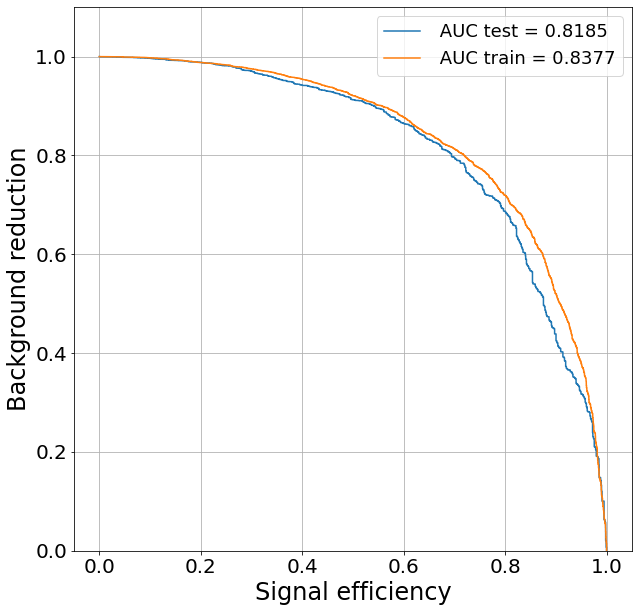

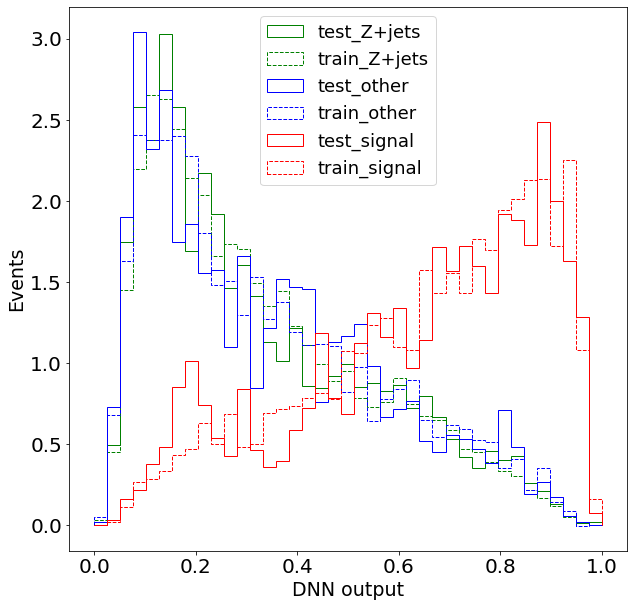

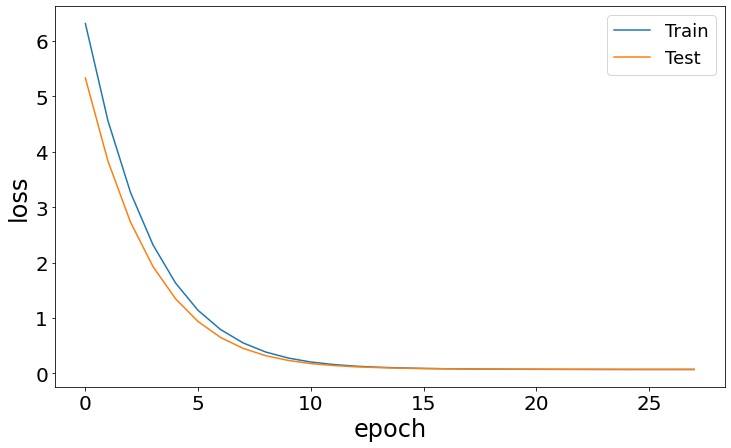

In [15]:
#plot results
from sklearn.metrics import auc, roc_curve
from keras.models import load_model
#model = load_model(res_dir+'\\model.h5')
model=DNN
predictions_NN= model.predict(X_test)
predictions_NN_train=model.predict(X_train)

#KS_test

from scipy import stats
ks_test_sig=stats.ks_2samp(predictions_NN[:,0][y_test['signal'] ==1],predictions_NN_train[:,0][y_train['signal'] ==1])
ks_test_bkg=stats.ks_2samp(predictions_NN[:,0][y_test['signal'] ==0],predictions_NN_train[:,0][y_train['signal'] ==0])

#plot AUC
plt.figure(figsize=(10,10))
fpr, tpr, threshold = roc_curve(y_test['signal'].astype('int32'),predictions_NN, pos_label=1, sample_weight=y_test['weight_'])
tpr.sort()
fpr.sort()
roc_auc =auc(fpr, tpr)
print ("AUC Score (Test): {:4%}".format(roc_auc))
plt.plot(tpr,(1-fpr), label =' AUC test = %0.4f' %(roc_auc))
fpr, tpr, threshold = roc_curve(y_train['signal'].astype('int32'),predictions_NN_train, pos_label=1, sample_weight=y_train['weight_'])
tpr.sort()
fpr.sort()
roc_auc =auc(fpr, tpr)
print ("AUC Score (Test): {:4%}".format(roc_auc))
plt.plot(tpr,(1-fpr), label =' AUC train = %0.4f' %(roc_auc))
plt.ylim(0,1.1)
plt.xlabel('Signal efficiency')
plt.ylabel('Background reduction')
#plt.title('NN ROC curve')
plt.grid()
plt.legend(loc='upper right')
plt.savefig(res_dir+'\\{}{}_{}_NNROC.pdf'.format(year,vers,cut))

#plot NN ouput by sample
plt.figure(figsize=(10,10))
groups=['DY','other','signal']
group_name=['Z+jets', 'other', 'signal']
color=['green','blue','red']
x=[]
nbins=40
for i,group in enumerate(groups):  
    plt.hist(predictions_NN[y_test['group']==group],bins=np.linspace(0,1,nbins), label='test_'+group_name[i], density=True, histtype='step', color=color[i], weights= y_test['weight_'][y_test['group']==group])
    plt.hist(predictions_NN_train[y_train['group']==group],bins=np.linspace(0,1,nbins), label='train_'+group_name[i], density=True, histtype='step', color=color[i], linestyle='dashed',weights= y_train['weight_'][y_train['group']==group])

plt.xlabel('DNN output',fontsize=19)
plt.ylabel('Events',fontsize=19)
#plt.title('NN output, sig ks pvalue = {:.3f}, bkg ks pvalue = {:.3f}'.format(ks_test_sig[1], ks_test_bkg[1]))
plt.legend(loc='upper center')
plt.savefig(res_dir+'\\{}{}_{}_NNOutput_Trainvstest.pdf'.format(year,vers,cut))


#plot loss
plt.figure(figsize=(12,7))
epochs = len(history.history['val_loss'])
x_axis = range(0, epochs)
#fig, ax = plt.subplots()
plt.plot(x_axis, history.history['loss'], label='Train')
plt.plot(x_axis, history.history['val_loss'], label='Test')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.draw()
plt.savefig(res_dir+'\\{}{}_{}_NNloss.png'.format(year,vers,cut))



# Retrain while splitting every X epochs to plot metrics evolution

In [ ]:
#predict every x epoch

DNN, NN_name=build_dnn(base_dir, lr, l1, l2, dp, sl1, sl2, sl3, sl4, sl5)
res_dir=base_dir+'\\'+year+'\\'+cut+'\\Res_{}'.format(NN_name)+vers
freq = 3
predictions_test={}
predictions_train={}

history={}
i=0
DNN, NN_name=build_dnn(base_dir, lr, l1, l2, dp, sl1, sl2, sl3, sl4, sl5)
history[i]=DNN.fit(x=np.asarray(X_train).astype(np.float32), y=np.asarray(y_train['signal']).astype(np.float32),
                sample_weight=np.asarray(y_train['w']).astype(np.float32), epochs=freq, batch_size=batchsize, 
                verbose=2, callbacks=[es_callback], 
                validation_data=(np.asarray(X_test).astype(np.float32), np.asarray(y_test['signal']).astype(np.float32),np.asarray(y_test['w']).astype(np.float32) )
               )


predictions_test[i]=DNN.predict(X_test)
predictions_train[i]=DNN.predict(X_train)

for i in range (1, int(epochs/freq)):
    print("training {}/{}".format(i, int(epochs/freq)))
    history[i]=DNN.fit(x=np.asarray(X_train).astype(np.float32), y=np.asarray(y_train['signal']).astype(np.float32),
                sample_weight=np.asarray(y_train['w']).astype(np.float32), epochs=freq, batch_size=batchsize, 
                verbose=2, callbacks=[es_callback], 
                validation_data=(np.asarray(X_test).astype(np.float32), np.asarray(y_test['signal']).astype(np.float32),np.asarray(y_test['w']).astype(np.float32) )
               )

    predictions_test[i]=DNN.predict(X_test)
    predictions_train[i]=DNN.predict(X_train)
   
    

In [ ]:
from scipy import stats
i = 0
ks_sig={}
ks_bkg={}
ks_sig[i]=stats.ks_2samp(predictions_test[i][:,0][y_test['signal'] ==1],predictions_train[i][:,0][y_train['signal'] ==1])[1]
ks_bkg[i]=stats.ks_2samp(predictions_test[i][:,0][y_test['signal'] ==0],predictions_train[i][:,0][y_train['signal'] ==0])[1]
S_test={}
B_test={}
S_train={}
B_train={}
co=0.8
S_test[i]=sum(y_test['weight_'][predictions_test[i][:,0]>=co][y_test['signal'][predictions_test[i][:,0]>=co] == 1])
S_train[i]=sum(y_train['weight_'][predictions_train[i][:,0]>=co][y_train['signal'][predictions_train[i][:,0]>=co] == 1])
B_test[i]=sum(y_test['weight_'][predictions_test[i][:,0]>=co][y_test['signal'][predictions_test[i][:,0]>=co] == 0])
B_train[i]=sum(y_train['weight_'][predictions_train[i][:,0]>=co][y_train['signal'][predictions_train[i][:,0]>=co] == 0])

for i in range (1, int(epochs/freq)):
    ks_sig[i]=stats.ks_2samp(predictions_test[i][:,0][y_test['signal'] ==1],predictions_train[i][:,0][y_train['signal'] ==1])[1]
    ks_bkg[i]=stats.ks_2samp(predictions_test[i][:,0][y_test['signal'] ==0],predictions_train[i][:,0][y_train['signal'] ==0])[1]
    S_test[i]=sum(y_test['weight_'][predictions_test[i][:,0]>=co][y_test['signal'][predictions_test[i][:,0]>=co] == 1])
    S_train[i]=sum(y_train['weight_'][predictions_train[i][:,0]>=co][y_train['signal'][predictions_train[i][:,0]>=co] == 1])
    B_test[i]=sum(y_test['weight_'][predictions_test[i][:,0]>=co][y_test['signal'][predictions_test[i][:,0]>=co] == 0])
    B_train[i]=sum(y_train['weight_'][predictions_train[i][:,0]>=co][y_train['signal'][predictions_train[i][:,0]>=co] == 0])


SoB_test=[]
SoB_train=[]
for i in range(0, len(S_test.values())):
    #print (S_test[i], B_test[i])
    SoB_test.append((S_test[i]/np.sqrt(B_test[i])))
    SoB_train.append((S_train[i]/np.sqrt(B_train[i])))
x=[i*freq for i in range(0, len(ks_sig))]
plt.plot(x, SoB_test)
plt.plot(x, SoB_train)
plt.savefig(res_dir+'\\{}{}_{}_SOB.png'.format(year,vers,cut))

plt.figure(figsize=(12,7))
x=[i*freq for i in range(0, len(ks_sig))]
plt.plot(x, ks_sig.values(), label ="ks signal pvalue")
plt.plot(x, ks_bkg.values(),label="ks bkg pvalue")
plt.hlines(0.05, 0, epochs, label = "0.05 pvalue", linestyle = "--", color = 'k')
plt.legend()
plt.xlabel("Number of epochs")
plt.ylabel("ks pvalue")
plt.ylim(0,1)
plt.title("Evolution of KS test during training")
plt.savefig(res_dir+'\\{}{}_{}_ks.png'.format(year,vers,cut))

# plot SHAP values

In [16]:
import shap
# select a set of background examples to take an expectation over
background = X_train.to_numpy()[np.random.choice(X_train.shape[0], 1000, replace=False)]
shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough
# explain predictions of the model on four images
explainer = shap.DeepExplainer(model, background)

shap_values = explainer.shap_values(X_test.to_numpy()[np.random.choice(X_test.shape[0], 1000, replace=False)])

# plot the feature attributions
#shap.image_plot(shap_values, -x_test[1:5])


If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.



keras is no longer supported, please use tf.keras instead.


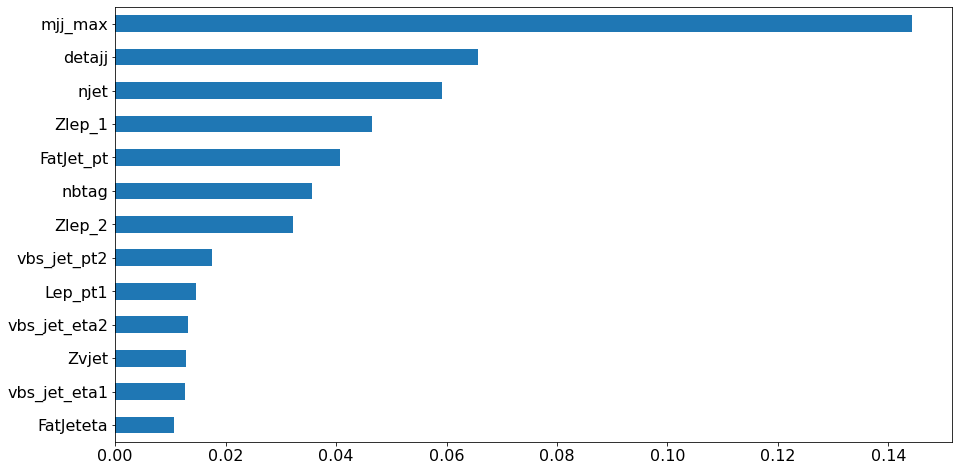

In [17]:
# intergated importance
shap_df=pd.DataFrame(shap_values[0], columns=input_list)
shap_mean=[]
for column in shap_df.columns:
    shap_mean.append(np.abs(shap_df[column]).mean())
abs(shap_df).mean().sort_values().plot(kind='barh', figsize=(15,8))
plt.savefig(res_dir+'/importance.png')

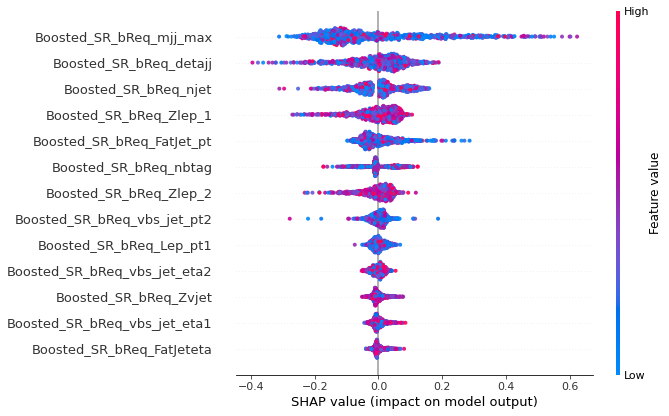

In [20]:
#Shap violin plot

plt.figure(figsize=(20,5), dpi=300)
shap.summary_plot(shap_values[0], X_test.to_numpy()[np.random.choice(X_test.shape[0], 1000, replace=False)],feature_names=X_test.columns, show = False, alpha=0.9)
plt.savefig(res_dir+'/importance_violin.png', bbox_inches='tight')
fig=plt.gcf()